# PROYECTO 1 – MODELO MLP PARA CLASIFICACIÓN DE PATOLOGÍAS RELACIONADAS CON OBESIDAD

# PASO 1 – PREPROCESAMIENTO DEL DATASET

## 1. Importación de librerías

In [54]:
import pandas as pd                     # Manipulación estructurada de datos
import numpy as np                      # Operaciones numéricas y arreglos
from sklearn.preprocessing import StandardScaler  # Normalización Z-score
from sklearn.model_selection import train_test_split  # División del dataset
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf                 # Framework de Deep Learning
import matplotlib.pyplot as plt         # Visualización de resultados

## 2. Carga del dataset

In [55]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(
    "Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.csv",
    sep=";"
)
# Lee el archivo CSV y lo convierte en DataFrame

print(df.head())  # Visualiza primeras filas
print(df.info())  # Muestra tipos de datos y valores nulos

Saving Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.csv to Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411 (5).csv
   FECHA_CORTE DEPARTAMENTO PROVINCIA                DISTRITO  UBIGEO  \
0     20241204         LIMA      LIMA              MIRAFLORES  150122   
1     20241204  LA LIBERTAD  TRUJILLO    VICTOR LARCO HERRERA  130111   
2     20241204    CAJAMARCA      JAEN                    JAEN   60801   
3     20241204         LIMA      LIMA  SAN JUAN DE LURIGANCHO  150132   
4     20241204       CALLAO    CALLAO              VENTANILLA   70106   

                           RED                                IPRESS  \
0   RED ASISTENCIAL REBAGLIATI                  H.III SUAREZ-ANGAMOS   
1  RED ASISTENCIAL LA LIBERTAD             POL. VICTOR LARCO HERRERA   
2         RED ASISTENCIAL JAEN                             H.II JAEN   
3     RED ASISTENCIAL ALMENARA        H.I AURELIO DIAZ-UFANO Y PERAL   

## 3. Limpieza de datos
- Eliminación de valores nulos
- Eliminación de columnas innecesarias

In [56]:
print("Valores nulos por columna:")
print(df.isna().sum())  # Cuenta valores nulos por columna

df = df.dropna()  # Elimina registros incompletos

print("Dimensión después de limpiar:", df.shape)

Valores nulos por columna:
FECHA_CORTE               0
DEPARTAMENTO              0
PROVINCIA                 0
DISTRITO                  0
UBIGEO                    0
RED                       0
IPRESS                    0
ID_PACIENTE               0
EDAD_PACIENTE             0
SEXO_PACIENTE             0
EDAD_MEDICO               0
ID_MEDICO                 0
COD_DIAG                  0
DIAGNOSTICO               0
AREA_HOSPITALARIA         0
SERVICIO_HOSPITALARIO     0
ACTIVIDAD_HOSPITALARIA    0
FECHA_MUESTRA             0
FEC_RESULTADO_1           0
DIFERIMIENTO_1            0
PROCEDIMIENTO_1           0
RESULTADO_1               0
UNIDADES_1                0
FEC_RESULTADO_2           0
PROCEDIMIENTO_2           0
RESULTADO_2               0
UNIDADES_2                0
DIFERIMIENTO_2            0
dtype: int64
Dimensión después de limpiar: (63799, 28)


In [57]:
df = df.drop(columns=["ID_Paciente"], errors='ignore')
# Elimina identificadores que no aportan al modelo

## 4. Transformación de variables categóricas
- Identificación de columnas tipo object
- Aplicación de get_dummies()

In [58]:
print(df.dtypes)

categoricas = df.select_dtypes(include='object').columns

print("Columnas categóricas:", categoricas)

FECHA_CORTE                 int64
DEPARTAMENTO               object
PROVINCIA                  object
DISTRITO                   object
UBIGEO                      int64
RED                        object
IPRESS                     object
ID_PACIENTE                object
EDAD_PACIENTE               int64
SEXO_PACIENTE              object
EDAD_MEDICO                 int64
ID_MEDICO                  object
COD_DIAG                   object
DIAGNOSTICO                object
AREA_HOSPITALARIA          object
SERVICIO_HOSPITALARIO      object
ACTIVIDAD_HOSPITALARIA     object
FECHA_MUESTRA               int64
FEC_RESULTADO_1             int64
DIFERIMIENTO_1              int64
PROCEDIMIENTO_1            object
RESULTADO_1               float64
UNIDADES_1                 object
FEC_RESULTADO_2             int64
PROCEDIMIENTO_2            object
RESULTADO_2               float64
UNIDADES_2                 object
DIFERIMIENTO_2              int64
dtype: object
Columnas categóricas: Index(['DEPA

In [59]:
# Identificar columnas categóricas
categoricas = df.select_dtypes(include='object').columns
print("Columnas categóricas:", categoricas)

# Aplicar Label Encoding
for col in categoricas:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print("Transformación completada")
print("Nueva dimensión:", df.shape)

Columnas categóricas: Index(['DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'RED', 'IPRESS', 'ID_PACIENTE',
       'SEXO_PACIENTE', 'ID_MEDICO', 'COD_DIAG', 'DIAGNOSTICO',
       'AREA_HOSPITALARIA', 'SERVICIO_HOSPITALARIO', 'ACTIVIDAD_HOSPITALARIA',
       'PROCEDIMIENTO_1', 'UNIDADES_1', 'PROCEDIMIENTO_2', 'UNIDADES_2'],
      dtype='object')
Transformación completada
Nueva dimensión: (63799, 28)


## 5. Estadísticas descriptivas


In [60]:
print(df.describe())  # Media, desviación, min, max

       FECHA_CORTE  DEPARTAMENTO     PROVINCIA      DISTRITO         UBIGEO  \
count      63799.0  63799.000000  63799.000000  63799.000000   63799.000000   
mean    20241204.0     11.763021     53.133074     96.384395  127856.792552   
std            0.0      5.319746     25.233870     55.523627   53102.685392   
min     20241204.0      0.000000      0.000000      0.000000   10101.000000   
25%     20241204.0      9.000000     41.000000     44.000000  100101.000000   
50%     20241204.0     14.000000     60.000000    104.000000  150101.000000   
75%     20241204.0     14.000000     65.000000    150.000000  150132.000000   
max     20241204.0     23.000000     97.000000    196.000000  240101.000000   

                RED        IPRESS   ID_PACIENTE  EDAD_PACIENTE  SEXO_PACIENTE  \
count  63799.000000  63799.000000  63799.000000   63799.000000   63799.000000   
mean      15.560714    150.326557  30630.664117      49.656107       0.286713   
std        9.348590     55.693406  17626.8522

# PASO 2 – DIVISIÓN DEL DATASET

## 6. Separación de variables y Normalización
- X (predictoras)
- y (objetivo)

In [61]:
df.columns = df.columns.str.lower()

# Separar variable objetivo y predictoras
y = df["resultado_1"]
X = df.drop(columns=["resultado_1"])

# Revisar cantidad de datos por clase (ANTES de codificar)
print("Conteo por clase original:")
print(y.value_counts())

# Eliminar clases con menos de 2 registros
conteo = y.value_counts()
clases_validas = conteo[conteo >= 2].index

df = df[df["resultado_1"].isin(clases_validas)]

# Volver a separar después del filtrado
y = df["resultado_1"]
X = df.drop(columns=["resultado_1"])

# Codificar etiquetas (AHORA SÍ)
from sklearn.preprocessing import LabelEncoder
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# Normalizar SOLO X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("X shape:", X.shape)
print("y shape:", y.shape)

Conteo por clase original:
resultado_1
90.00     911
94.00     885
93.00     880
95.00     872
91.00     852
         ... 
255.86      1
40.90       1
81.86       1
229.13      1
145.30      1
Name: count, Length: 11311, dtype: int64
X shape: (57524, 27)
y shape: (57524,)


## 7. División Train / Validation / Test
- 70% entrenamiento
- 15% validación
- 15% prueba

In [62]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,       # 30% para val+test
    shuffle=True,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,       # 15% val – 15% test
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (40266, 27)
Validation: (8629, 27)
Test: (8629, 27)


## 8. Conversión de datos
- Conversión a TensorFlow

In [63]:
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_val   = tf.convert_to_tensor(X_val, dtype=tf.float32)
X_test  = tf.convert_to_tensor(X_test, dtype=tf.float32)

y_train = tf.convert_to_tensor(y_train, dtype=tf.int32)
y_val   = tf.convert_to_tensor(y_val, dtype=tf.int32)
y_test  = tf.convert_to_tensor(y_test, dtype=tf.int32)

# PASO 3 – DISEÑO DEL MODELO

## 9. Arquitectura del MLP
- Capa oculta 1: 64 neuronas – ReLU
- Capa oculta 2: 32 neuronas – ReLU
- Capa de salida: 1 neurona – Sigmoid

In [64]:
numero_clases = len(np.unique(y_train))
print("Número de clases:", numero_clases)

model = tf.keras.Sequential([

    tf.keras.Input(shape=(X_train.shape[1],)),  # Entrada

    tf.keras.layers.Dense(64, activation='relu'),  # Capa oculta 1
    tf.keras.layers.Dense(32, activation='relu'),  # Capa oculta 2

    tf.keras.layers.Dense(numero_clases, activation='softmax')  # Salida multiclase
])

model.summary()

Número de clases: 5036


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5036)           │       166,188 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,060 (664.30 KB)

 Trainable params: 170,060 (664.30 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
tf.keras.layers.Dense(numero_clases, activation='softmax')

<Dense name=dense_25, built=False>

## 10. Compilación
- Optimizer: Adam
- Loss: binary_crossentropy
- Métrica: accuracy

In [66]:
model.compile(
    optimizer='adam',                # Algoritmo de optimización
    loss='sparse_categorical_crossentropy',      # Función de pérdida
    metrics=['accuracy']             # Métrica solicitada
)

## 11. Entrenamiento
- Épocas: 10
- Batch size: 128
- Validación incluida

In [67]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.0125 - loss: 7.3800 - val_accuracy: 0.0140 - val_loss: 6.4626
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.0161 - loss: 6.3220 - val_accuracy: 0.0154 - val_loss: 6.4014
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.0174 - loss: 6.1959 - val_accuracy: 0.0176 - val_loss: 6.3907
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.0187 - loss: 6.0842 - val_accuracy: 0.0181 - val_loss: 6.4099
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.0191 - loss: 6.0052 - val_accuracy: 0.0166 - val_loss: 6.4400
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.0186 - loss: 5.9194 - val_accuracy: 0.0154 - val_loss: 6.4823
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.0207 - loss: 5.8552 - val_accuracy: 0.0161 - val_loss: 6.5482
Epoch 8/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.0202 - loss: 5.7355 - val_ac

# PASO 4 – AJUSTE DE HIPERPARÁMETROS

## 12. Pruebas con distintas configuraciones
- Variación en número de neuronas
- Variación en número de capas
- Cambio de optimizador
- Comparación en validación

In [68]:
model_mejorado = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(numero_clases, activation='softmax')
])
# Variación en número de neuronas y capas

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# PASO 5 – EVALUACIÓN FINAL

## 13. Evaluación en conjunto de prueba
- model.evaluate()
- Accuracy final

In [69]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Accuracy en Test:", test_accuracy)

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0181 - loss: 6.9066
Accuracy en Test: 0.015413141809403896


## 14. Análisis de resultados
- Comparación Train vs Validation
- Observación de posible overfitting

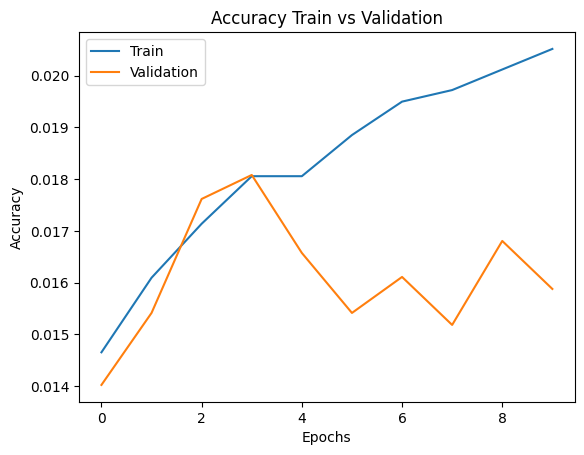

In [70]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Train vs Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()